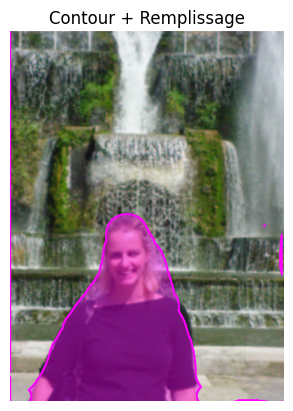

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


image = cv2.imread("photo.png")

mask = cv2.imread("mask.png", cv2.IMREAD_GRAYSCALE)

contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

copyimage = image.copy()

cv2.drawContours(copyimage, contours, -1, (255, 0, 255), -1)

alpha = 0.4
image_with_fill = cv2.addWeighted(copyimage, alpha, image, 1 - alpha, 0)

cv2.drawContours(image_with_fill, contours, -1, (255, 0, 255), 2)

plt.imshow(cv2.cvtColor(image_with_fill, cv2.COLOR_BGR2RGB))
plt.title("Contour + Remplissage")
plt.axis("off")
plt.show()


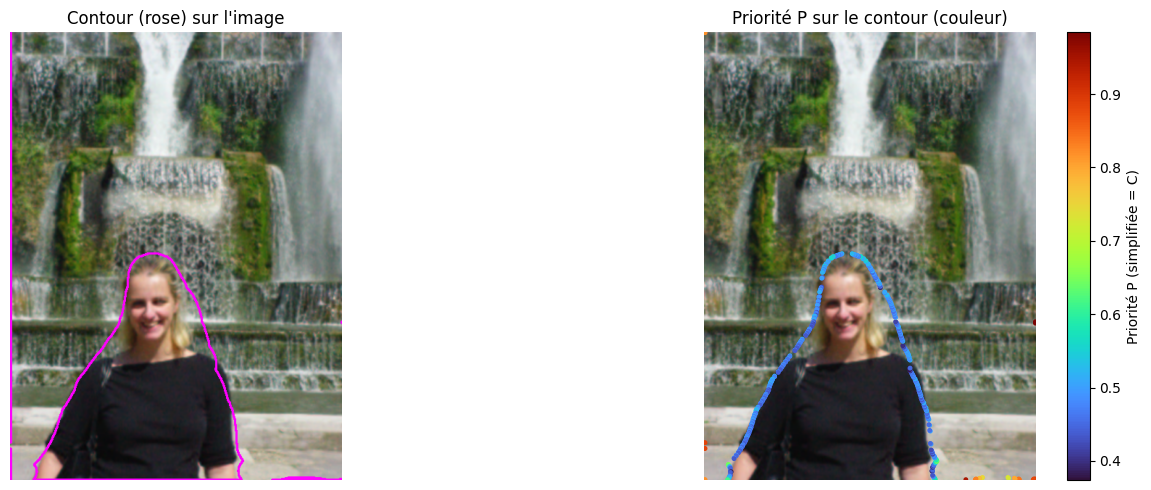

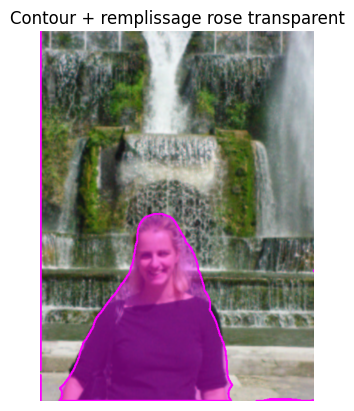

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("photo.png")                             
mask  = cv2.imread("mask.png", cv2.IMREAD_GRAYSCALE)  #blanc  =  aenlever , noir  a garder

_, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

# on adapte le masque a l'image  (taille)
if (mask.shape[0] != image.shape[0]) or (mask.shape[1] != image.shape[1]):
    mask = cv2.resize(mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)

#findcontour du mask
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#confiance C
# C = 1  partout C = 0 dans la zone blanche du masque (a remplir)
C = np.ones_like(mask, dtype=np.float32)
C[mask == 255] = 0.0

#priorité simplifiee
# On définit un patch autour de chaque point p du contour et on prend la moyenne de C dans ce patch
# (version débutante : D = 1, donc P(p) = C_moyenne_autour_de_p)
patch_radius = 9                        #a deter
h, w = mask.shape[:2]

# Pour visualiser : on va stocker P sur les points du contour
contour_xy = []     # liste des (x, y) des points du contour
P_values   = []     # liste des P(p) correspondants

for cnt in contours:
    for pt in cnt:
        x, y = int(pt[0][0]), int(pt[0][1])

        # bornes du patch (on clippe dans l'image)
        x0 = max(0, x - patch_radius)
        x1 = min(w, x + patch_radius + 1)
        y0 = max(0, y - patch_radius)
        y1 = min(h, y + patch_radius + 1)

        C_patch = C[y0:y1, x0:x1]
        C_avg = float(C_patch.mean())   # moyenne de confiance autour de p

        contour_xy.append((x, y))
        P_values.append(C_avg)

P_values = np.array(P_values, dtype=np.float32)  # déjà dans [0,1]


# Image + contour rose
img_contour = image.copy()
cv2.drawContours(img_contour, contours, -1, (255, 0, 255), 2)   # rose (BGR)

#Image + carte de priorités du contour
img_P = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # pour affichage correct dans matplotlib
xs = [x for (x, y) in contour_xy]
ys = [y for (x, y) in contour_xy]

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img_contour, cv2.COLOR_BGR2RGB))
plt.title("Contour (rose) sur l'image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_P)
sc = plt.scatter(xs, ys, c=P_values, s=6, cmap='turbo')  # couleur = priorité P (0→1)
plt.colorbar(sc, fraction=0.046, pad=0.04, label="Priorité P (simplifiée = C)")
plt.title("Priorité P sur le contour (couleur)")
plt.axis("off")

plt.tight_layout()
plt.show()

overlay = image.copy()
cv2.drawContours(overlay, contours, -1, (255, 0, 255), -1)   # remplir en rose
alpha = 0.4
img_fill = cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0)
cv2.drawContours(img_fill, contours, -1, (255, 0, 255), 2)   # contour rose 

plt.imshow(cv2.cvtColor(img_fill, cv2.COLOR_BGR2RGB))
plt.title("Contour + remplissage rose transparent")
plt.axis("off")
plt.show()
